# Importing Required Python libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.neural_network import MLPClassifier

# Exploratory Data Analysis

In [ ]:
eighteen = pd.read_csv('/content/18.csv')
eighteen.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


Names and its Datatypes

In [ ]:
print("Dataset Information:")
print(f"Number of samples: {eighteen.shape[0]}")
print(f"Number of features: {eighteen.shape[1]}")
print("\nData Types:")
print(eighteen.dtypes)

Dataset Information:
Number of samples: 8068
Number of features: 11

Data Types:
ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
Segmentation        object
dtype: object


Spliting into numerical and categorical features

In [ ]:
##Selecting numerical features
numerical_data = eighteen.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

#Selecting categoricalfeatures
categorical_data=eighteen.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'\nThere are {len(categorical_features)} Catagorical features:', '\n')
print(categorical_features)

There are 4 numerical features: 

['ID', 'Age', 'Work_Experience', 'Family_Size']

There are 7 Catagorical features: 

['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']


Satistics of Numerical Features

In [ ]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,8068.0,463479.214551,2595.381232,458982.0,461240.75,463472.5,465744.25,467974.0
Age,8068.0,43.466906,16.711696,18.0,30.00,40.0,53.00,89.0
Work_Experience,7239.0,2.641663,3.406763,0.0,0.00,1.0,4.00,14.0
Family_Size,7733.0,2.850123,1.531413,1.0,2.00,3.0,4.00,9.0


Satistics of Categorical features

In [ ]:
# Transposed stats for categorical features

categorical_data.describe().T

,count,unique,top,freq
Gender,8068,2,Male,4417
Ever_Married,7928,2,Yes,4643
Graduated,7990,2,Yes,4968
Profession,7944,9,Artist,2516
Spending_Score,8068,3,Low,4878
Var_1,7992,7,Cat_6,5238
Segmentation,8068,4,D,2268


Variance of each numerical features

In [ ]:
numerical_data.var()

,0
ID,6.736004e+06
Age,2.792808e+02
Work_Experience,1.160603e+01
Family_Size,2.345227e+00


Skew in numerical features

In [ ]:
numerical_data.skew()

,0
ID,0.002435
Age,0.696021
Work_Experience,1.306226
Family_Size,1.010804


Histograms and Box Plot

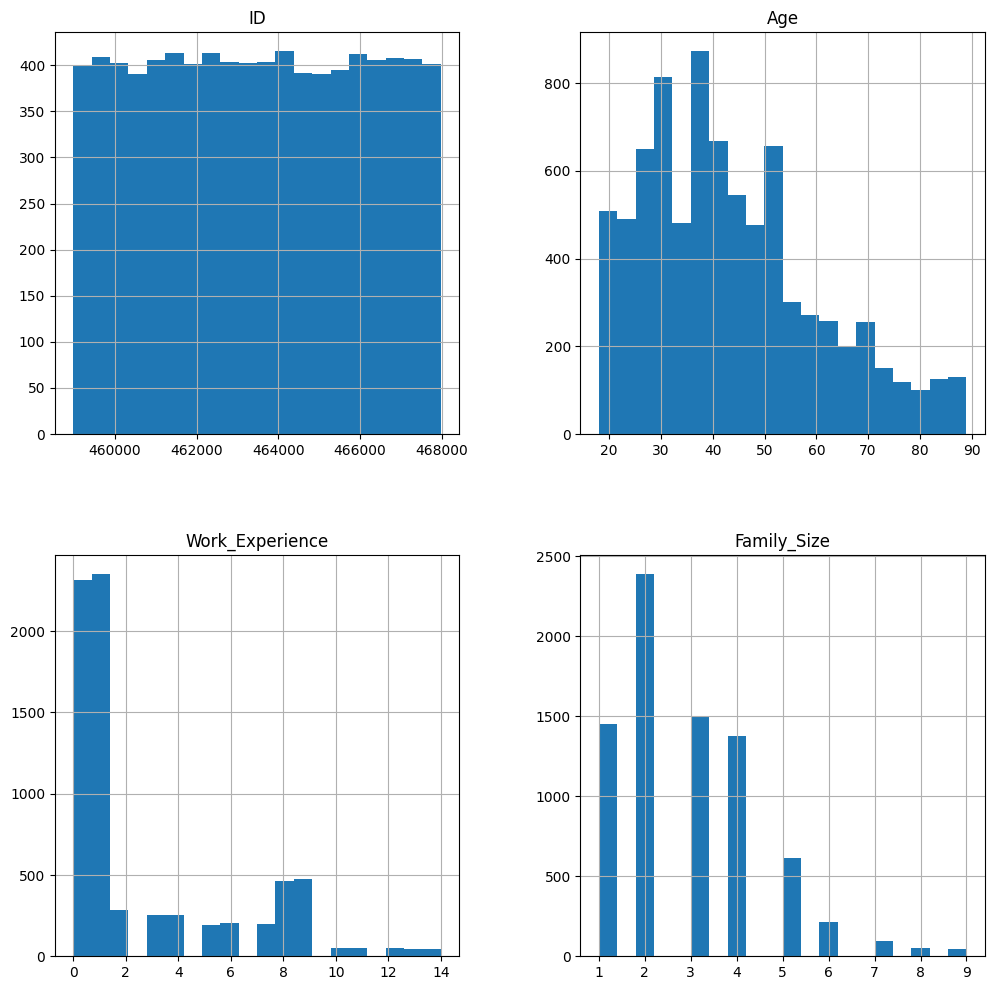

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

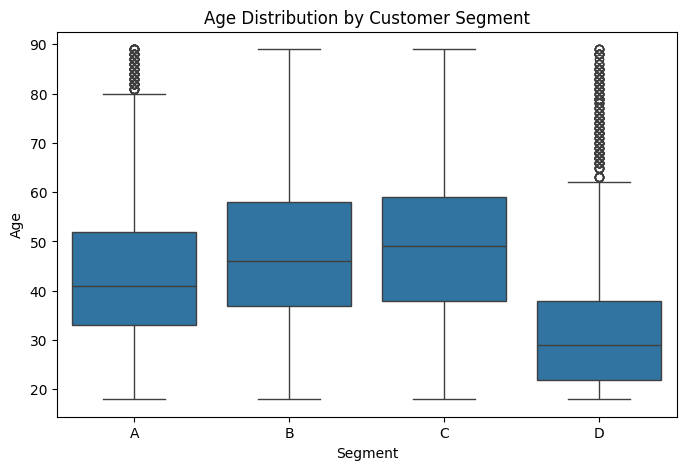

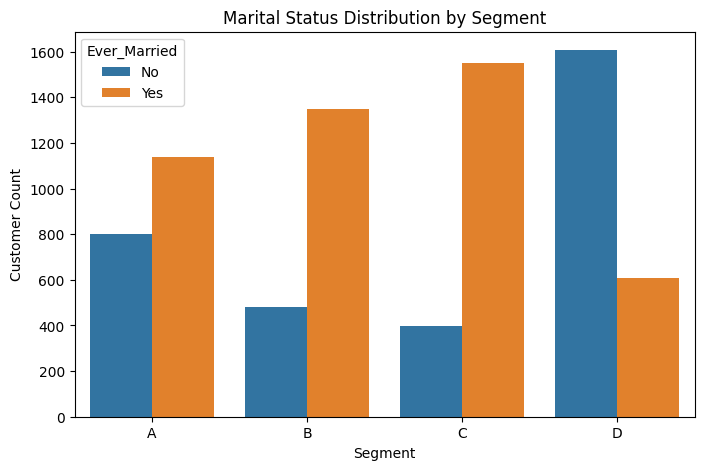

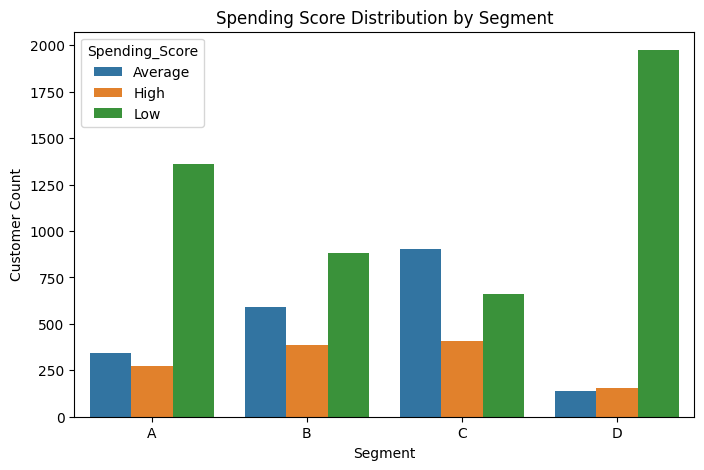

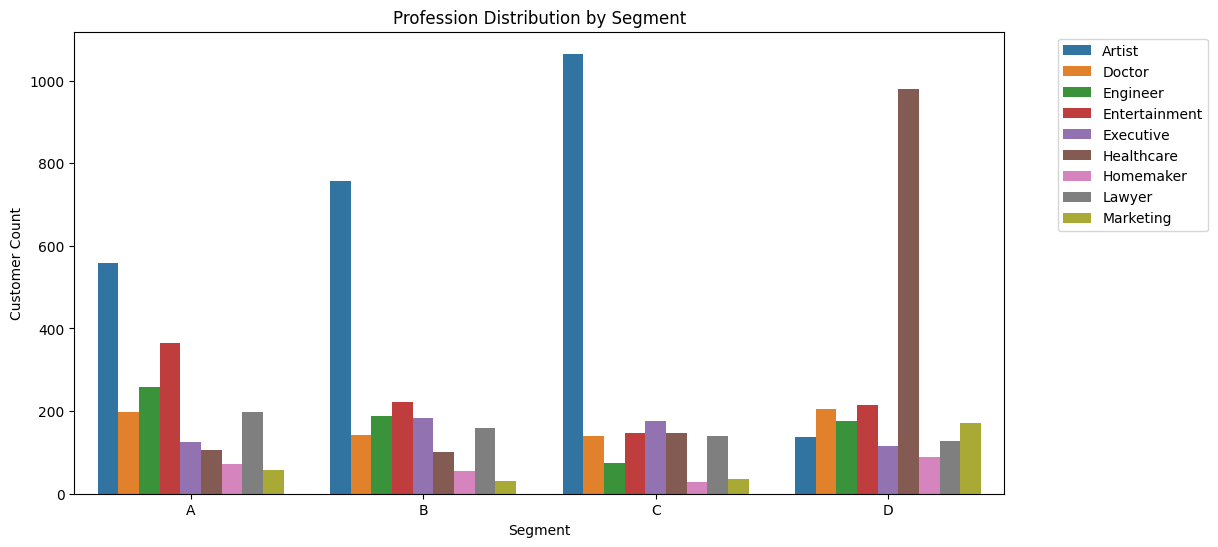

In [ ]:
# Load the dataset
df = pd.read_csv("/content/18.csv")

# Clean minimal missing values for plotting
df = df[df['Segmentation'].notna()]

# === 1. Boxplot: Age Distribution by Segment ===
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Segmentation', y='Age', order=['A', 'B', 'C', 'D'])
plt.title('Age Distribution by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Age')
plt.show()

# === 2. Barplot: Marital Status by Segment ===
married_counts = df.groupby(['Segmentation', 'Ever_Married']).size().reset_index(name='Count')
plt.figure(figsize=(8, 5))
sns.barplot(data=married_counts, x='Segmentation', y='Count', hue='Ever_Married', order=['A', 'B', 'C', 'D'])
plt.title('Marital Status Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Customer Count')
plt.show()

# === 3. Barplot: Spending Score by Segment ===
spending_counts = df.groupby(['Segmentation', 'Spending_Score']).size().reset_index(name='Count')
plt.figure(figsize=(8, 5))
sns.barplot(data=spending_counts, x='Segmentation', y='Count', hue='Spending_Score', order=['A', 'B', 'C', 'D'])
plt.title('Spending Score Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Customer Count')
plt.show()

# === 4. Barplot: Profession Distribution by Segment ===
profession_counts = df.groupby(['Segmentation', 'Profession']).size().reset_index(name='Count')
plt.figure(figsize=(12, 6))
sns.barplot(data=profession_counts, x='Segmentation', y='Count', hue='Profession', order=['A', 'B', 'C', 'D'])
plt.title('Profession Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Customer Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



Barplot of unique value counts in every categorical features

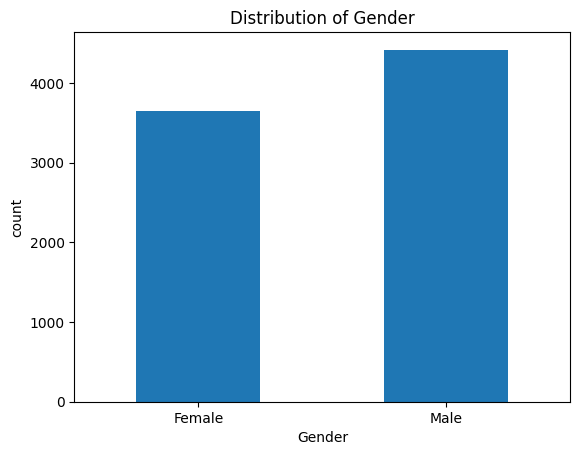

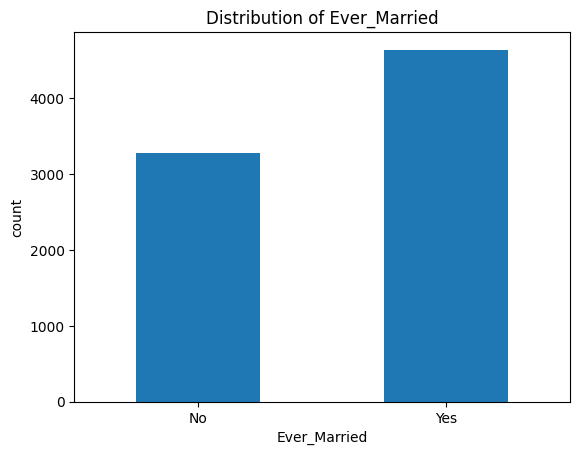

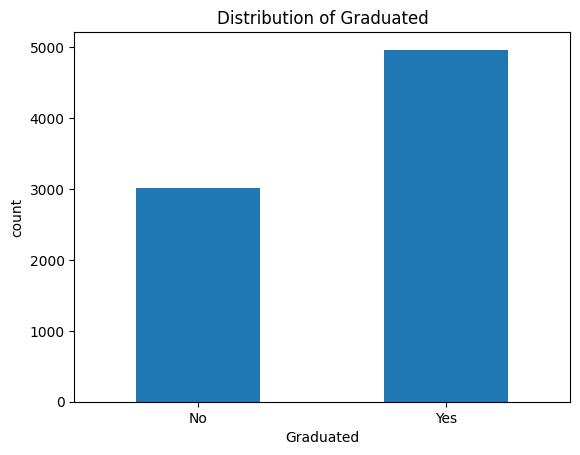

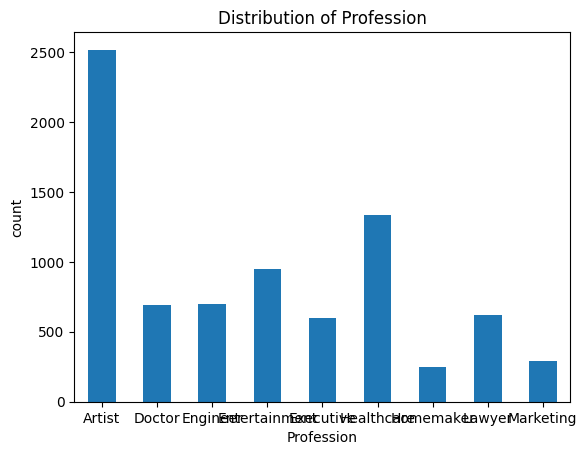

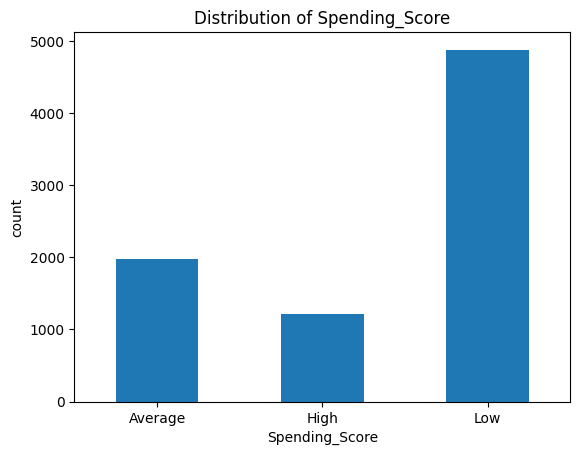

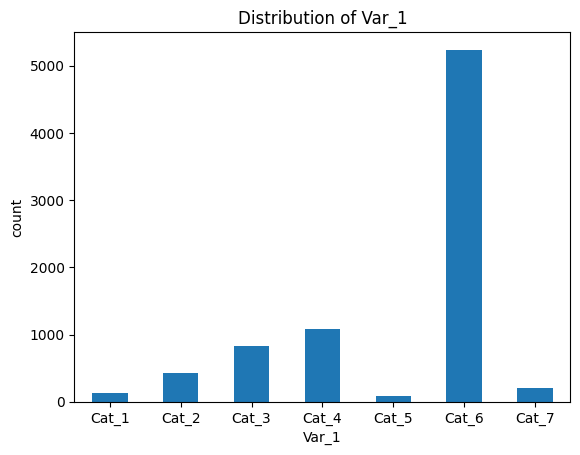

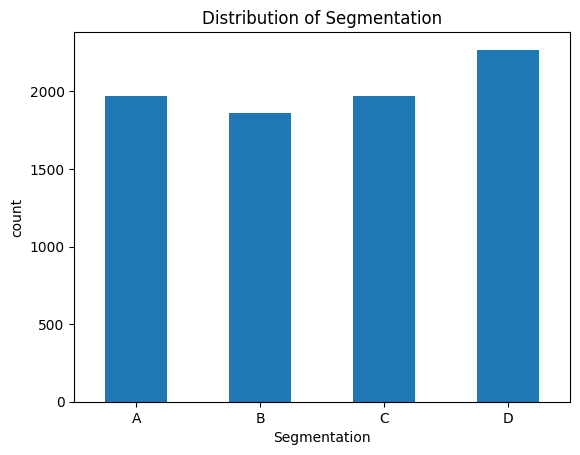

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

Barplot of Outcome vs Percentage

In [ ]:
#check Imbalance in data

#group instances based on the classes in OUTCOME variable
class_counts=eighteen.groupby("Segmentation").size()

# Get unique segment labels
segments = class_counts.index.tolist()

# Prepare data for DataFrame
data = []
for segment in segments:
    count = class_counts[segment]
    percentage = (count / len(eighteen)) * 100  # Calculate percentage based on total data
    data.append([segment, count, percentage])

# Create DataFrame
columns=['Segmentation','count','percentage']
imbalance_df=pd.DataFrame(data, columns=columns)
imbalance_df

,Segmentation,count,percentage
0,A,1972,24.442241
1,B,1858,23.029251
2,C,1970,24.417452
3,D,2268,28.111056


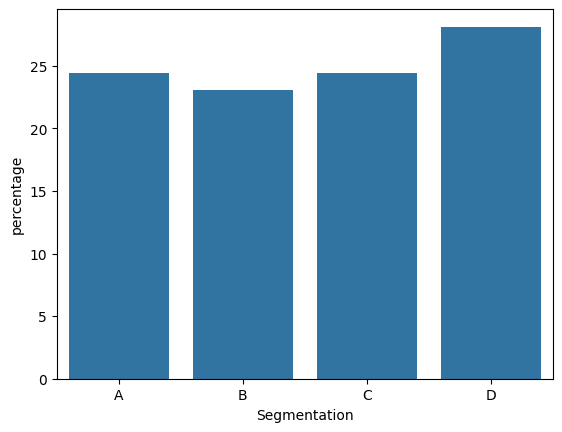

In [ ]:
sns.barplot(data=imbalance_df,x=imbalance_df['Segmentation'],y=imbalance_df['percentage'])
plt.show()

Density plots of numerical features

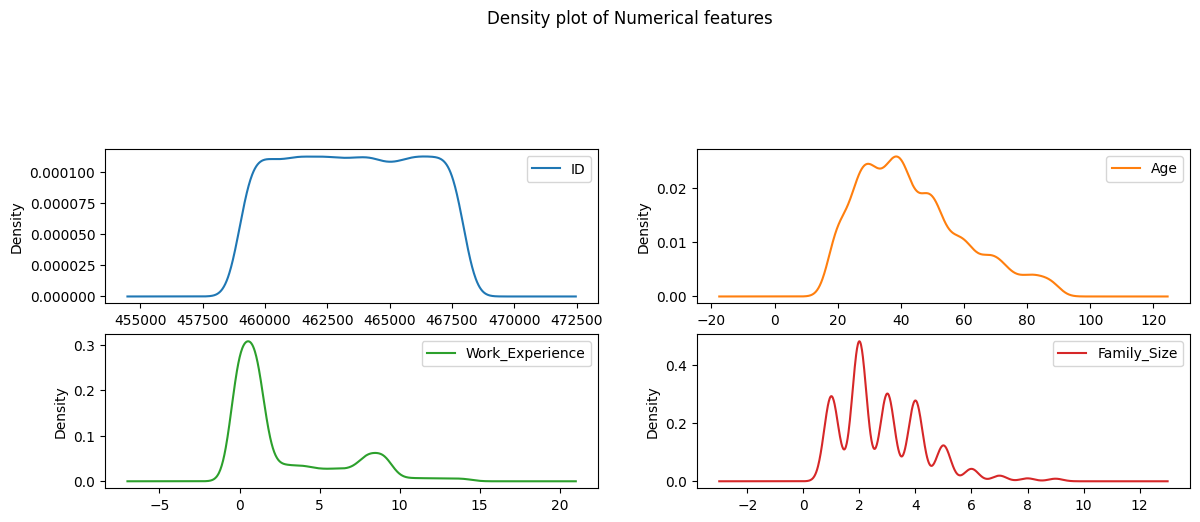

In [ ]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

# Dataset Pre-processing

In [ ]:
print("Missing values count per column:")
print(eighteen.isnull().sum())

Missing values count per column:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64


Dropping Null values

In [ ]:
#droping column / irrelavant column
eighteen = eighteen.drop('ID', axis = 1)
#droping  row/duplicates
eighteen = eighteen.drop_duplicates()
eighteen = eighteen.dropna(axis = 0, subset = ['Work_Experience','Family_Size'])
print(eighteen.shape)
print(eighteen.isnull().sum())

(6577, 10)
Gender               0
Ever_Married       107
Age                  0
Graduated           60
Profession          92
Work_Experience      0
Spending_Score       0
Family_Size          0
Var_1               56
Segmentation         0
dtype: int64


Imputing Null values

In [ ]:
impute = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

impute.fit(eighteen[['Ever_Married']])


eighteen['Ever_Married'] = impute.transform(eighteen[['Ever_Married']])[:, 0]

impute.fit(eighteen[['Graduated']])


eighteen['Graduated'] = impute.transform(eighteen[['Graduated']])[:, 0]

impute.fit(eighteen[['Profession']])

eighteen['Profession'] = impute.transform(eighteen[['Profession']])[:, 0]

impute.fit(eighteen[['Var_1']])


eighteen['Var_1'] = impute.transform(eighteen[['Var_1']])[:, 0]

print(eighteen.isnull().sum())

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64


Scaling Numerical Feutures

In [ ]:
#minmax scaling
x_numerical_cols = eighteen.select_dtypes(include=np.number).columns[:-1]
scaler = MinMaxScaler()

eighteen[x_numerical_cols] = scaler.fit_transform(eighteen[x_numerical_cols])
eighteen.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,0.056338,No,Healthcare,0.071429,Low,4.0,Cat_4,D
2,Female,Yes,0.690141,Yes,Engineer,0.071429,Low,1.0,Cat_6,B
3,Male,Yes,0.690141,Yes,Lawyer,0.000000,High,2.0,Cat_6,B
5,Male,Yes,0.535211,No,Artist,0.000000,Average,2.0,Cat_6,C
6,Male,No,0.197183,Yes,Healthcare,0.071429,Low,3.0,Cat_6,C


Labeling Catagorical Values

In [ ]:
le = LabelEncoder()
categorical_cols = eighteen.select_dtypes(include=['object']).columns
for col in categorical_cols:
  eighteen[col] = le.fit_transform(eighteen[col])

eighteen.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,1,0,0.056338,0,5,0.071429,2,4.0,3,3
2,0,1,0.690141,1,2,0.071429,2,1.0,5,1
3,1,1,0.690141,1,7,0.000000,1,2.0,5,1
5,1,1,0.535211,0,0,0.000000,0,2.0,5,2
6,1,0,0.197183,1,5,0.071429,2,3.0,5,2


Correlation_matrix

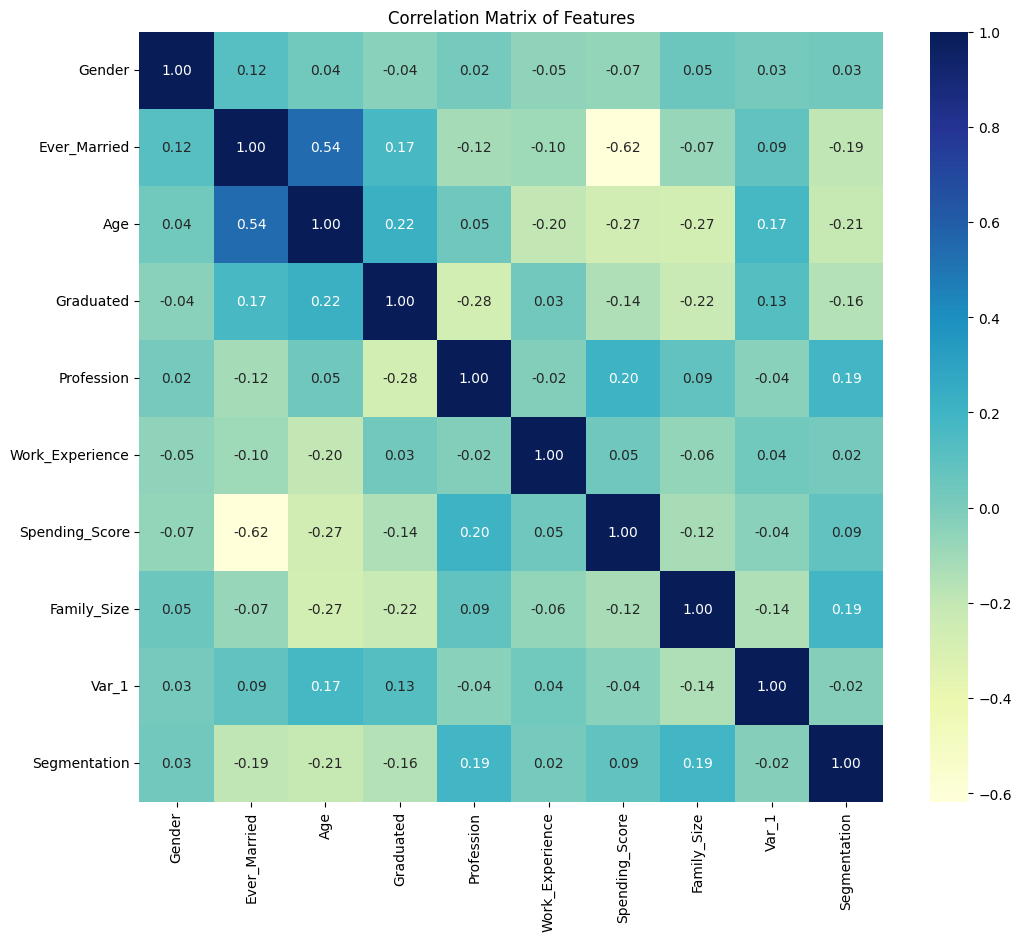

In [ ]:
correlation_matrix = eighteen.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Model Training

Spliting Dataset

In [ ]:
#splition to train and test
X = eighteen.iloc[:, :-1]
#last  column
Y = eighteen.iloc[:, -1]
#Split the data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Training Neural Network

In [ ]:
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
nn_model.fit(x_train, y_train)
y_pred_nn = nn_model.predict(x_test)

Training Decision Tree & Logistic Regression

In [ ]:
lm = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
lm.fit(x_train, y_train)

y_pred_lm = lm.predict(x_test)


dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# Model Evaluation

Confusion Matrix of the trained models

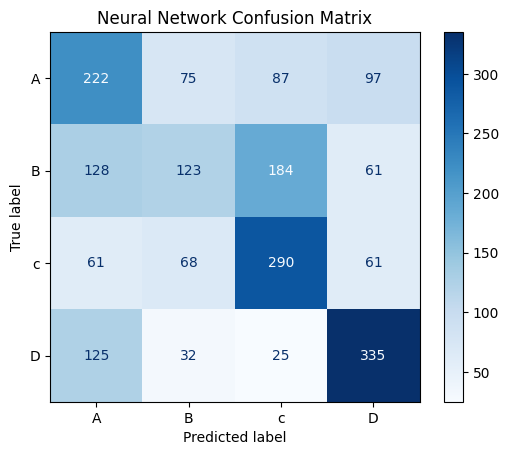

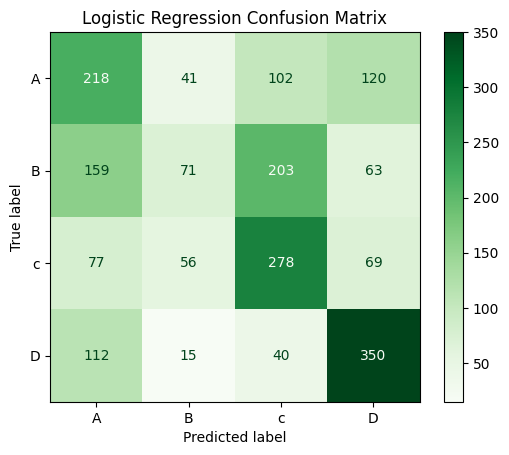

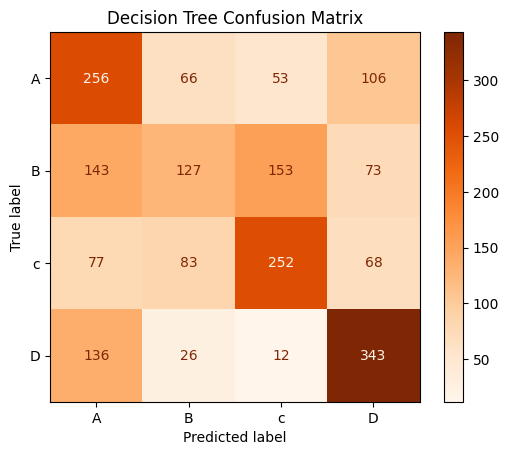

Neural Network Accuracy: 0.49138804457953394
Logistic Regression Accuracy: 0.4645390070921986
Decision Tree Accuracy: 0.49544072948328266


In [ ]:
label= ["A","B","c","D"] # also use np.unique(Y)

# Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn)
ConfusionMatrixDisplay(cm_nn, display_labels=label).plot(cmap="Blues")
plt.title("Neural Network Confusion Matrix")
plt.show()


# Gaussian Naive Bayesn
cm_lm = confusion_matrix(y_test, y_pred_lm)
ConfusionMatrixDisplay(cm_lm, display_labels=label).plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=label).plot(cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.show()


# Accuracy comparison
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lm))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Showcasing prediction accuracy and f1 score of all models

In [ ]:
print("Neural Network :")
print(classification_report(y_test, y_pred_nn, target_names=label))

print("logistic Regression  :")
print(classification_report(y_test, y_pred_lm, target_names=label))

print("Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=label))

Neural Network :
              precision    recall  f1-score   support

           A       0.41      0.46      0.44       481
           B       0.41      0.25      0.31       496
           c       0.49      0.60      0.54       480
           D       0.60      0.65      0.63       517

    accuracy                           0.49      1974
   macro avg       0.48      0.49      0.48      1974
weighted avg       0.48      0.49      0.48      1974

logistic Regression  :
              precision    recall  f1-score   support

           A       0.39      0.45      0.42       481
           B       0.39      0.14      0.21       496
           c       0.45      0.58      0.50       480
           D       0.58      0.68      0.63       517

    accuracy                           0.46      1974
   macro avg       0.45      0.46      0.44      1974
weighted avg       0.45      0.46      0.44      1974

Decision Tree:
              precision    recall  f1-score   support

           A       0

Bar chart of accuracy and f1 score

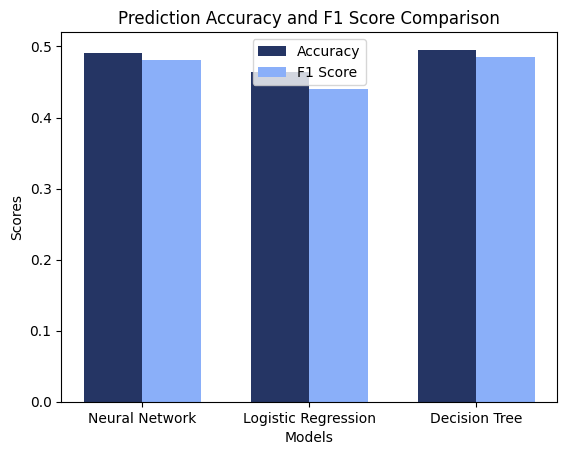

In [ ]:
# Calculate accuracy and F1 scores
accuracy_nn = accuracy_score(y_test, y_pred_nn)
accuracy_gnb = accuracy_score(y_test, y_pred_lm)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

f1_nn = f1_score(y_test, y_pred_nn, average='weighted')
f1_gnb = f1_score(y_test, y_pred_lm, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

# Bar chart for accuracy and F1 scores
models = ['Neural Network', 'Logistic Regression', 'Decision Tree']
accuracy_scores = [accuracy_nn, accuracy_gnb, accuracy_dt]
f1_scores = [f1_nn, f1_gnb, f1_dt]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, accuracy_scores, width, label='Accuracy',color='#253564')
plt.bar(x + width/2, f1_scores, width, label='F1 Score',color='#8AAFF9')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Prediction Accuracy and F1 Score Comparison')
plt.xticks(x, models)
plt.legend()
plt.show()

AUC score, ROC curve

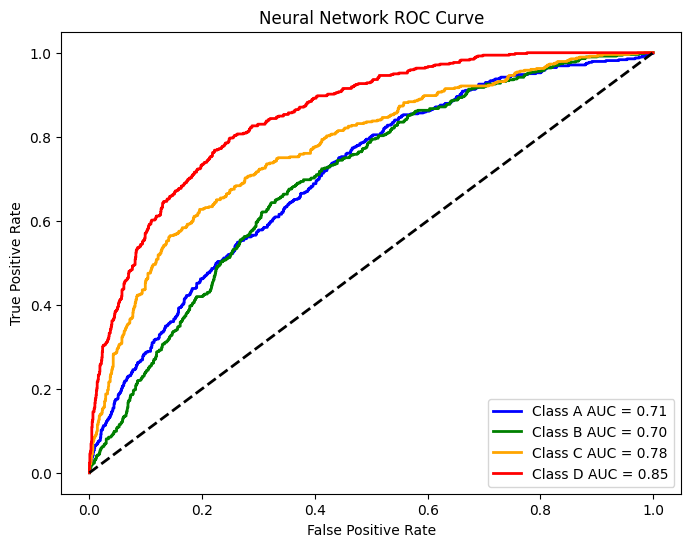

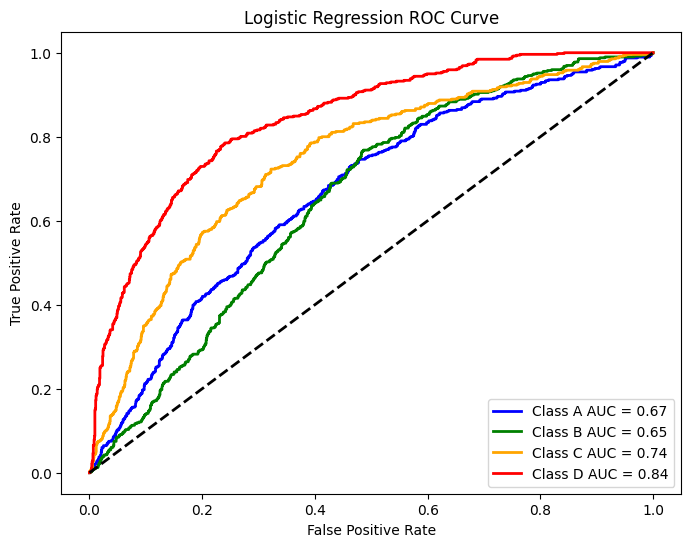

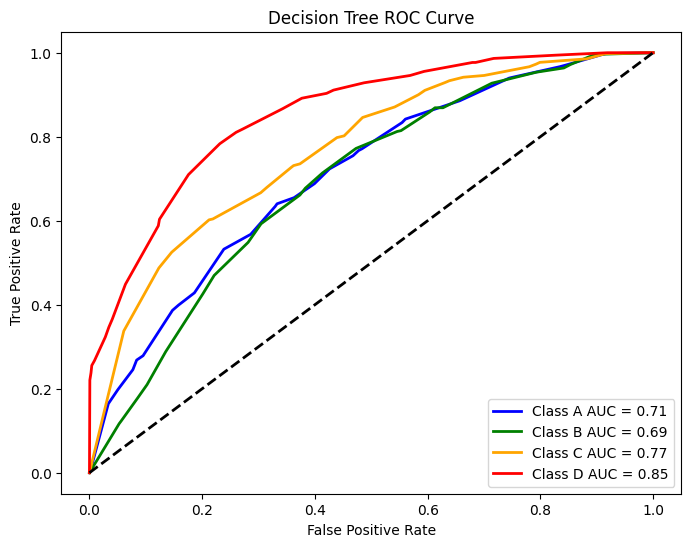

Neural Network AUC: 0.7590226480949032
Logistic Regression AUC: 0.7265276653009685
Decision Tree AUC: 0.7558003116300931


In [ ]:
# Binarize the labels for multiclass ROC and AUC
y_test_binarized = label_binarize(y_test, classes=np.unique(Y))
n_classes = y_test_binarized.shape[1]

# Neural Network AUC and ROC
y_pred_nn_prob = nn_model.predict_proba(x_test)
auc_nn = roc_auc_score(y_test_binarized, y_pred_nn_prob, multi_class='ovr')

# Logistic Regression AUC and ROC
y_pred_lm_prob = lm.predict_proba(x_test)
auc_lm = roc_auc_score(y_test_binarized, y_pred_lm_prob, multi_class='ovr')

# Decision Tree AUC and ROC
y_pred_dt_prob = dt.predict_proba(x_test)
auc_dt = roc_auc_score(y_test_binarized, y_pred_dt_prob, multi_class='ovr')

# Plot ROC curve for Neural Network
class_names = ["A","B","C","D"]
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'green', 'orange','red'])
for class_idx, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_idx], y_pred_nn_prob[:, class_idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {class_names[class_idx]} AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Neural Network ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Plot ROC curve for Logistic Regression
plt.figure(figsize=(8, 6))
for class_idx, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_idx], y_pred_lm_prob[:, class_idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {class_names[class_idx]} AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Logistic Regression ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Plot ROC curve for Decision Tree
plt.figure(figsize=(8, 6))
for class_idx, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_idx], y_pred_dt_prob[:, class_idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {class_names[class_idx]} AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Decision Tree ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Print AUC scores for each model
print("Neural Network AUC:", auc_nn)
print("Logistic Regression AUC:", auc_lm)
print("Decision Tree AUC:", auc_dt)